# Netflix Customer Churn Analysis

## SWYNEX Technologies – Data Analyst Internship

### Final Data Analytics Project

**Objective:** Analyze customer churn patterns, identify high-risk customer segments, and provide data-driven recommendations to improve customer retention.

**Tools Used:**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Power BI
- Jupyter Notebook
- GitHub

## 1. Business Problem

Customer churn is an important business challenge for subscription-based platforms such as Netflix.

The objective of this project is to analyze customer data and identify patterns associated with customer churn. The analysis focuses on subscription type, region, device usage, payment method, and customer engagement behavior.

The findings are presented through exploratory data analysis and an interactive Power BI dashboard to support data-driven business decisions.

## 2. Project Objectives

The main objectives of this project are:

1. Understand the characteristics of the customer dataset.
2. Clean and prepare the data for analysis.
3. Analyze overall customer churn.
4. Identify customer segments with higher churn rates.
5. Analyze the relationship between customer engagement and churn.
6. Build an interactive dashboard for business reporting.
7. Generate actionable business insights and recommendations.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/netflix_customer_churn_cleaned.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (5000, 15)


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,watch_hours_to_avg_ratio
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,30.061224
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,23.333333
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,11.027027
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,12.885714
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,14.538462


## 3. Dataset Information

The dataset contains customer-level information related to a Netflix-style subscription service.

It includes customer demographics, subscription details, viewing behavior, account characteristics, and churn status.

### Dataset Dimensions

- **Rows:** 5,000 customers
- **Columns:** 15
- **Target Variable:** `churned`
- **Churned Customer:** `1`
- **Retained Customer:** `0`

### Main Feature Categories

| Category | Features |
|---|---|
| Customer Information | customer_id, age, gender |
| Subscription | subscription_type, monthly_fee |
| Engagement | watch_hours, avg_watch_time_per_day, last_login_days |
| Location & Device | region, device |
| Account | number_of_profiles, payment_method |
| Preferences | favorite_genre |
| Churn | churned |
| Derived Feature | watch_hours_to_avg_ratio |

## 4. Data Cleaning Summary

The dataset used in this final analysis was prepared during Task 1: Data Cleaning & Preparation.

The cleaning process included:

- Checking the dataset structure and data types.
- Identifying missing values.
- Checking for duplicate records.
- Validating categorical and numerical fields.
- Checking values for consistency.
- Preparing the cleaned dataset for exploratory analysis.
- Creating a derived engagement-related feature: `watch_hours_to_avg_ratio`.

The cleaned dataset from Task 1 is used as the input for this final project.

In [21]:
print("===== DATA QUALITY CHECK =====")

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

===== DATA QUALITY CHECK =====
Dataset Shape: (5000, 15)

Missing Values:
customer_id                 0
age                         0
gender                      0
subscription_type           0
watch_hours                 0
last_login_days             0
region                      0
device                      0
monthly_fee                 0
churned                     0
payment_method              0
number_of_profiles          0
avg_watch_time_per_day      0
favorite_genre              0
watch_hours_to_avg_ratio    0
dtype: int64

Duplicate Rows: 0

Data Types:
customer_id                  object
age                           int64
gender                       object
subscription_type            object
watch_hours                 float64
last_login_days               int64
region                       object
device                       object
monthly_fee                 float64
churned                       int64
payment_method               object
number_of_profiles            int64

## 5. Overall Customer Churn Analysis

The first step is to understand the overall distribution of retained and churned customers.

The churn rate is calculated as the percentage of customers whose `churned` value is 1.

In [22]:
total_customers = len(df)
churned_customers = df["churned"].sum()
retained_customers = total_customers - churned_customers
churn_rate = (churned_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Overall Churn Rate:", round(churn_rate, 2), "%")

Total Customers: 5000
Churned Customers: 2515
Retained Customers: 2485
Overall Churn Rate: 50.3 %


## 6. Churn Analysis by Subscription Type

Subscription type is analyzed to determine whether churn varies across Basic, Standard, and Premium customers.

Churn rate is calculated as:

**Churn Rate = Churned Customers / Total Customers × 100**

In [23]:
subscription_analysis = (
    df.groupby("subscription_type")["churned"]
    .agg(
        total_customers="count",
        churned_customers="sum",
        churn_rate="mean"
    )
    .reset_index()
)

subscription_analysis["churn_rate"] = (
    subscription_analysis["churn_rate"] * 100
).round(2)

subscription_analysis = subscription_analysis.sort_values(
    "churn_rate",
    ascending=False
)

display(subscription_analysis)

,subscription_type,total_customers,churned_customers,churn_rate
0,Basic,1661,1027,61.83
2,Standard,1646,748,45.44
1,Premium,1693,740,43.71


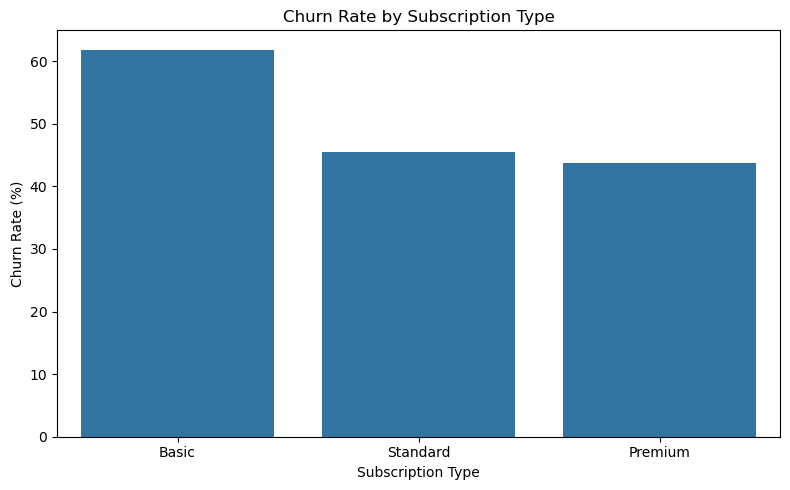

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=subscription_analysis,
    x="subscription_type",
    y="churn_rate"
)

plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

## 7. Churn Analysis by Region

Regional analysis is used to identify geographic segments with relatively higher customer churn.

In [25]:
region_analysis = (
    df.groupby("region")["churned"]
    .agg(
        total_customers="count",
        churned_customers="sum",
        churn_rate="mean"
    )
    .reset_index()
)

region_analysis["churn_rate"] = (
    region_analysis["churn_rate"] * 100
).round(2)

region_analysis = region_analysis.sort_values(
    "churn_rate",
    ascending=False
)

display(region_analysis)

,region,total_customers,churned_customers,churn_rate
2,Europe,867,448,51.67
5,South America,873,449,51.43
1,Asia,841,426,50.65
4,Oceania,765,383,50.07
3,North America,851,421,49.47
0,Africa,803,388,48.32


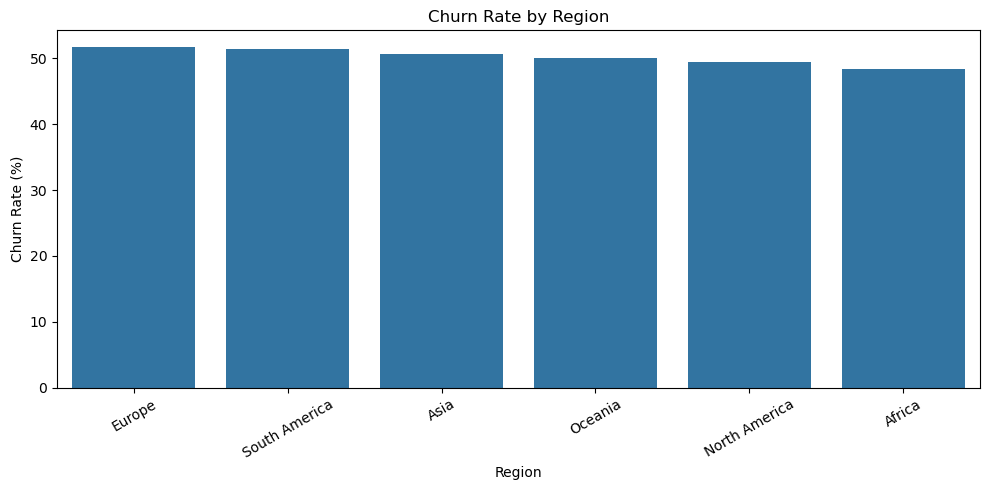

In [26]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=region_analysis,
    x="region",
    y="churn_rate"
)

plt.title("Churn Rate by Region")
plt.xlabel("Region")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. Churn Analysis by Device

Device-level analysis helps determine whether customer churn varies across the platforms used to access the service.

In [27]:
device_analysis = (
    df.groupby("device")["churned"]
    .agg(
        total_customers="count",
        churned_customers="sum",
        churn_rate="mean"
    )
    .reset_index()
)

device_analysis["churn_rate"] = (
    device_analysis["churn_rate"] * 100
).round(2)

device_analysis = device_analysis.sort_values(
    "churn_rate",
    ascending=False
)

display(device_analysis)

,device,total_customers,churned_customers,churn_rate
1,Laptop,1006,521,51.79
2,Mobile,1004,507,50.50
4,Tablet,1048,524,50.00
3,TV,993,496,49.95
0,Desktop,949,467,49.21


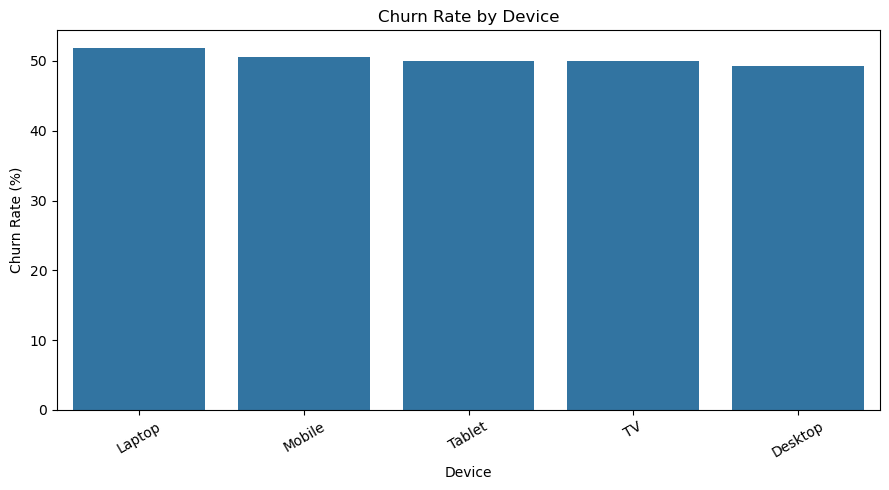

In [28]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=device_analysis,
    x="device",
    y="churn_rate"
)

plt.title("Churn Rate by Device")
plt.xlabel("Device")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 9. Churn Analysis by Payment Method

Payment method is analyzed to determine whether churn rates differ across payment preferences.

In [29]:
payment_analysis = (
    df.groupby("payment_method")["churned"]
    .agg(
        total_customers="count",
        churned_customers="sum",
        churn_rate="mean"
    )
    .reset_index()
)

payment_analysis["churn_rate"] = (
    payment_analysis["churn_rate"] * 100
).round(2)

payment_analysis = payment_analysis.sort_values(
    "churn_rate",
    ascending=False
)

display(payment_analysis)

,payment_method,total_customers,churned_customers,churn_rate
1,Crypto,995,594,59.70
3,Gift Card,976,564,57.79
4,PayPal,1026,483,47.08
2,Debit Card,1030,450,43.69
0,Credit Card,973,424,43.58


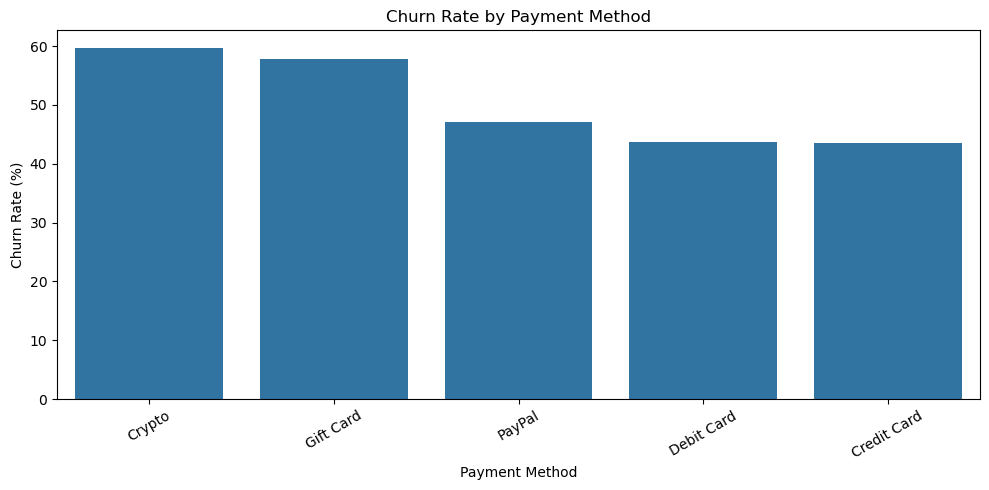

In [30]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=payment_analysis,
    x="payment_method",
    y="churn_rate"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 10. Customer Engagement and Behavioral Analysis

Customer engagement metrics are compared between retained and churned customers to identify behavioral differences associated with churn.

The analysis focuses on viewing activity, login recency, subscription fee, daily watch time, and account profiles.

In [31]:
behavior_analysis = df.groupby("churned")[
    [
        "watch_hours",
        "last_login_days",
        "monthly_fee",
        "avg_watch_time_per_day",
        "number_of_profiles"
    ]
].mean().round(2)

behavior_analysis.index = ["Retained", "Churned"]

display(behavior_analysis)

,watch_hours,last_login_days,monthly_fee,avg_watch_time_per_day,number_of_profiles
Retained,17.45,21.77,14.25,1.59,3.25
Churned,5.92,38.31,13.13,0.16,2.80


## 11. Watch Hours by Churn Status

Average watch hours are compared between retained and churned customers to examine differences in overall viewing engagement.


In [32]:
watch_comparison = (
    df.groupby("churned")["watch_hours"]
    .mean()
    .reset_index()
)

watch_comparison["churn_status"] = watch_comparison["churned"].map({
    0: "Retained",
    1: "Churned"
})

display(watch_comparison)

,churned,watch_hours,churn_status
0,0,17.449590,Retained
1,1,5.918497,Churned


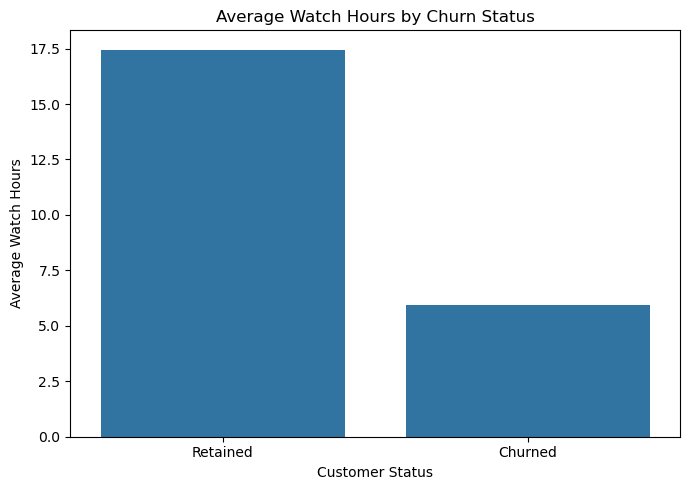

In [33]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=watch_comparison,
    x="churn_status",
    y="watch_hours"
)

plt.title("Average Watch Hours by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Watch Hours")
plt.tight_layout()
plt.show()

## 12. Last Login Analysis

The average number of days since the customer's last login is compared between retained and churned customers.

A higher value may indicate lower recent engagement, although this analysis alone does not establish causation.

In [34]:
login_analysis = (
    df.groupby("churned")["last_login_days"]
    .mean()
    .reset_index()
)

login_analysis["churn_status"] = login_analysis["churned"].map({
    0: "Retained",
    1: "Churned"
})

display(login_analysis)

,churned,last_login_days,churn_status
0,0,21.771026,Retained
1,1,38.309344,Churned


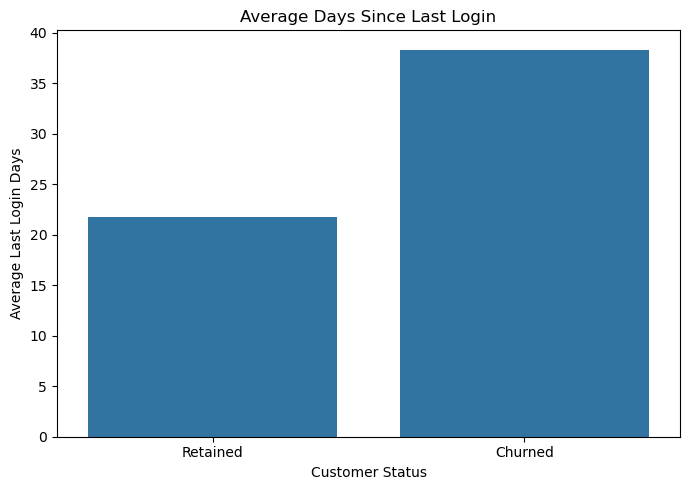

In [35]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=login_analysis,
    x="churn_status",
    y="last_login_days"
)

plt.title("Average Days Since Last Login")
plt.xlabel("Customer Status")
plt.ylabel("Average Last Login Days")
plt.tight_layout()
plt.show()

## 13. Interactive Power BI Dashboard

An interactive Power BI dashboard was developed as part of Task 3 to provide a visual overview of customer churn.

The dashboard includes:

- Total Customers
- Churned Customers
- Retained Customers
- Churn Rate
- Average Watch Hours
- Customer churn distribution
- Churn by subscription type
- Churn by region
- Churn by device
- Interactive slicers for filtering the analysis

The dashboard allows users to explore customer churn patterns interactively and supports business-focused decision making.

 — Interactive Dashboard

An interactive Power BI dashboard was created to provide a visual overview of customer churn.

Dashboard screenshot:

![Netflix Customer Churn Dashboard](task_3_dashboard/dashboard_screenshot.png)

In [36]:
print("===== FINAL ANALYSIS SUMMARY =====")

print("\nSUBSCRIPTION:")
display(subscription_analysis)

print("\nREGION:")
display(region_analysis)

print("\nDEVICE:")
display(device_analysis)

print("\nPAYMENT:")
display(payment_analysis)

print("\nCUSTOMER BEHAVIOR:")
display(behavior_analysis)

===== FINAL ANALYSIS SUMMARY =====

SUBSCRIPTION:


,subscription_type,total_customers,churned_customers,churn_rate
0,Basic,1661,1027,61.83
2,Standard,1646,748,45.44
1,Premium,1693,740,43.71



REGION:


,region,total_customers,churned_customers,churn_rate
2,Europe,867,448,51.67
5,South America,873,449,51.43
1,Asia,841,426,50.65
4,Oceania,765,383,50.07
3,North America,851,421,49.47
0,Africa,803,388,48.32



DEVICE:


,device,total_customers,churned_customers,churn_rate
1,Laptop,1006,521,51.79
2,Mobile,1004,507,50.50
4,Tablet,1048,524,50.00
3,TV,993,496,49.95
0,Desktop,949,467,49.21



PAYMENT:


,payment_method,total_customers,churned_customers,churn_rate
1,Crypto,995,594,59.70
3,Gift Card,976,564,57.79
4,PayPal,1026,483,47.08
2,Debit Card,1030,450,43.69
0,Credit Card,973,424,43.58



CUSTOMER BEHAVIOR:


,watch_hours,last_login_days,monthly_fee,avg_watch_time_per_day,number_of_profiles
Retained,17.45,21.77,14.25,1.59,3.25
Churned,5.92,38.31,13.13,0.16,2.80


## 14. Key Business Insights

Based on the customer churn analysis, the following business insights were identified:

### 1. Basic Subscribers Have the Highest Churn Rate

Basic subscribers have the highest churn rate at **61.83%**, compared with **45.44%** for Standard subscribers and **43.71%** for Premium subscribers.

This indicates that the Basic subscription segment should be prioritized for customer retention analysis and targeted engagement strategies.

### 2. Crypto and Gift Card Users Show Higher Churn

Customers using **Crypto** have the highest churn rate at **59.70%**, followed by **Gift Card** users at **57.79%**.

In comparison, Credit Card and Debit Card users have churn rates of approximately **43.6%**.

This suggests that payment-method segments should be monitored as part of churn-risk analysis.

### 3. Churned Customers Show Lower Viewing Engagement

Retained customers have average watch hours of **17.45**, while churned customers have average watch hours of only **5.92**.

The substantial difference suggests that lower viewing engagement is strongly associated with customer churn.

### 4. Churned Customers Have Longer Login Gaps

Retained customers have an average of **21.77 days** since their last login, while churned customers have an average of **38.31 days**.

This indicates that reduced recent activity may be an important warning signal for potential churn.

### 5. Device Type Shows Limited Difference

Churn rates across devices range from approximately **49.21% to 51.79%**.

Laptop users have the highest observed device-level churn rate at **51.79%**, while Desktop users have the lowest at **49.21%**.

The relatively small difference suggests that device type is less important for churn segmentation than subscription type, payment method, and customer engagement.

### 6. Overall Churn Represents a Significant Business Challenge

The dataset contains **5,000 customers**, of whom **2,515 are churned**, resulting in an overall churn rate of **50.30%**.

This indicates a substantial customer-retention challenge and highlights the importance of identifying high-risk segments and improving customer engagement.

## 15. Business Recommendations

Based on the analysis, the following recommendations can be considered:

1. **Focus retention campaigns on Basic subscribers**  
   Develop targeted offers, engagement campaigns, or plan-value improvements for Basic customers.

2. **Monitor high-churn payment segments**  
   Investigate customers using Crypto and Gift Cards and evaluate whether payment experience, customer behavior, or other factors are associated with their higher churn.

3. **Create an early-warning engagement system**  
   Customers with declining watch hours or increasing days since their last login could be identified as potential churn-risk customers.

4. **Improve customer engagement**  
   Personalized content recommendations, reminders, and relevant content discovery can be used to encourage customers to return to the platform.

5. **Use the Power BI dashboard for continuous monitoring**  
   Business teams can monitor churn by subscription, region, device, and other customer segments and track changes over time.

6. **Prioritize data-driven retention strategies**  
   Retention efforts should focus on measurable customer behavior and high-risk segments rather than applying the same strategy to every customer.

## 16. Conclusion

The analysis identified several customer segments and behavioral patterns associated with churn. Basic subscribers and customers using Crypto or Gift Card payment methods showed higher observed churn rates, while churned customers demonstrated substantially lower viewing activity and longer gaps since their last login.

The combination of Python-based analysis and the Power BI dashboard provides a practical framework for monitoring churn and identifying high-risk customer segments. These insights can help businesses develop more targeted customer engagement and retention strategies.